# Phase 3 - Experiment 1, Domain 2 (Graphs): Evaluation

Evaluates the Phase 2 model results for the graph domain.

**Input:** `phase2_model_results_graph/<NN_model>/<model>_results.json`
**Output:** `figures/fig1..fig5.png`, `results/evaluation_summary.txt`, `results/v4flash_failure_analysis.json`

Adapted from the Geometry domain's `phase3_evaluation/Geometry_Experiment1_Phase3.ipynb`
(same statistical machinery: bootstrap CIs, gap analysis, Spearman consistency,
significance tests) with the property set, local/global split, and domain-specific
figures swapped for this domain's 8 graph properties.

CELL 2 reads the Phase 2 logs straight from the repo when present, and falls
back to a manual Colab upload otherwise.

**No production Phase 2 data exists in this repository yet** (see
`../phase2_model_results_graph/README.md`) -- the six models have not been
queried against real APIs. This notebook is built and logic-tested against
synthetic mock data (not committed); running it for real once Phase 2 has
produced results is a matter of re-executing the cells in order.

## [CELL 1] Setup: imports, constants, output paths, shared plot style

In [4]:
"""
Phase 3 - Experiment 1, Domain 2 (Graphs): evaluation of the Phase 2 model results.

INPUT   phase2_model_results_graph/<NN_model>/<model>_results.json   (produced in Phase 2)
OUTPUT  figures/fig1..fig5.png
        results/evaluation_summary.txt
        results/v4flash_failure_analysis.json
        results/phase3_console_output.txt   (if run via `python run_phase3_evaluation.py | tee ...`)

Run headless:   python run_phase3_evaluation.py
Run in Colab:   upload this repo folder, or let CELL 2 fall back to manual upload.
"""
import json
import math
import os
import random
import statistics
import sys
import textwrap
from collections import Counter
from pathlib import Path

import numpy as np

import matplotlib
IN_COLAB = "google.colab" in sys.modules
if not IN_COLAB and not os.environ.get("DISPLAY") and os.name != "nt":
    matplotlib.use("Agg")          # headless-safe; must precede the pyplot import
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde, spearmanr

# --- Models (order = display order). Value = short label for tables/figures. ---
# NOTE: keys are exactly the strings in each result log's "model" field.
# Same six models/ids as the Geometry domain (PDF Table 1 is domain-agnostic).
DISPLAY = {
    "deepseek-v4-flash":        "V4-Flash",
    "qwen/qwen3-32b":           "Qwen3-32B",
    "meta-llama/llama-4-scout": "Llama4-Scout",
    "gemini-2.5-flash-lite":    "Gemini2.5-FL",
    "gpt-4.1-mini":             "GPT-4.1-mini",
    "deepseek-v4-pro":          "V4-Pro*",   # * = 20% subsample, thinking DISABLED
}
MODEL_ORDER = list(DISPLAY.keys())
SUBSAMPLE_MODELS = {"deepseek-v4-pro"}       # ran on 20% (60 graphs); kept out of paired tests

# --- Complexity tiers and graph families ---
TIERS = ["simple", "medium", "hard"]
FAMILIES = ["erdos_renyi", "barabasi_albert", "watts_strogatz", "random_bipartite", "random_planar"]

# --- The 8 graph properties, fixed display order (local first, then global) ---
PROP_ORDER = [
    "degree_of_node_0", "edge_count",                                    # local
    "triangle_count", "is_bipartite", "is_planar", "diameter",           # global
    "chromatic_number", "avg_clustering",                                # global
]
LOCAL  = {"degree_of_node_0", "edge_count"}
GLOBAL = set(PROP_ORDER) - LOCAL

# Only avg_clustering is graded by relative-error tolerance band; everything
# else in this domain is exact match (int or bool) -- unlike Geometry, where
# 6 of 9 properties were numeric-tolerance. That is a real domain difference,
# not a simplification: bbox/centroid/area/perimeter/aspect_ratio/edge_length_variance
# have no graph analogue among these 8 properties.
NUMERIC_TOL = {"avg_clustering"}
EXACT       = set(PROP_ORDER) - NUMERIC_TOL
BOOLEAN     = {"is_bipartite", "is_planar"}
CATEGORICAL: set[str] = set()   # no cw/ccw-style categorical property in this domain

# Global properties that require actual computation, shown as accuracy-vs-tier
# lines in Fig 2 (boolean globals get confusion-matrix treatment instead, Cell 7).
COMPUTED_GLOBALS = ["triangle_count", "diameter", "chromatic_number", "avg_clustering"]

# --- Tolerance levels for numeric accuracy (protocol Table 13) ---
TOLERANCES = [("correct_1pct", "1%"), ("correct_5pct", "5%"), ("correct_10pct", "10%")]

# --- Statistical reporting settings (protocol 6.4) ---
BOOTSTRAP_N = 10000
CI_LEVEL    = 95
RNG_SEED    = 0

# --- Output locations: every savefig / open() goes through these ---
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
FIG_DIR  = BASE_DIR / "figures"
OUT_DIR  = BASE_DIR / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Shared visual identity: ONE definition used by every figure ---
MODEL_STYLE = {
    "deepseek-v4-flash":        dict(color="#E63946", ls="-",  lw=2.0, marker="o", ms=7),
    "qwen/qwen3-32b":           dict(color="#F4A261", ls="-",  lw=2.0, marker="s", ms=7),
    "meta-llama/llama-4-scout": dict(color="#2A9D8F", ls="-",  lw=2.0, marker="^", ms=7),
    "gemini-2.5-flash-lite":    dict(color="#6A0572", ls="-",  lw=2.0, marker="D", ms=7),
    "gpt-4.1-mini":             dict(color="#0077B6", ls="-",  lw=2.0, marker="P", ms=7),
    "deepseek-v4-pro":          dict(color="#333333", ls="--", lw=2.5, marker="*", ms=9),
}
TIER_COLORS = {"simple": "#4C9F70", "medium": "#E1A730", "hard": "#C0504D"}


def mstyle(m):
    """Plot kwargs for model m (grey dotted fallback = key mismatch)."""
    return MODEL_STYLE.get(m, dict(color="grey", ls=":", lw=1.5, marker="x", ms=6))


def mlabel(m):
    """Human-readable model label; the star marks the 20% subsample model."""
    base = DISPLAY.get(m, m)
    return base + "  * (20% subsample)" if m in SUBSAMPLE_MODELS else base


assert len(PROP_ORDER) == 8
assert NUMERIC_TOL | EXACT == set(PROP_ORDER)
print("Setup done.")
print("Models:", [DISPLAY[m] for m in MODEL_ORDER])
print("Properties (local):", sorted(LOCAL))
print("Properties (global):", sorted(GLOBAL))
print(f"Bootstrap: {BOOTSTRAP_N} resamples, {CI_LEVEL}% CI, seed {RNG_SEED}")
print(f"Figures -> {FIG_DIR}")
print(f"Results -> {OUT_DIR}")

Setup done.
Models: ['V4-Flash', 'Qwen3-32B', 'Llama4-Scout', 'Gemini2.5-FL', 'GPT-4.1-mini', 'V4-Pro*']
Properties (local): ['degree_of_node_0', 'edge_count']
Properties (global): ['avg_clustering', 'chromatic_number', 'diameter', 'is_bipartite', 'is_planar', 'triangle_count']
Bootstrap: 10000 resamples, 95% CI, seed 0
Figures -> /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/figures
Results -> /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/results


## [CELL 2] Load the Phase 2 result logs (repo-first, Colab-upload fallback)

In [5]:
# Phase 3's inputs ARE Phase 2's outputs, so read them straight from the repo.

PHASE2_CANDIDATES = [
    BASE_DIR / ".." / "phase2_model_results_graph",   # normal repo layout
    BASE_DIR / "phase2_model_results_graph",
    Path("/content/phase2_model_results_graph"),      # if you copy the folder into Colab
    BASE_DIR / "data",                                # local scratch fallback
]


def _find_result_files():
    for d in PHASE2_CANDIDATES:
        d = Path(d)
        if not d.is_dir():
            continue
        # per-model subfolders first (01_v4flash/v4flash_results.json), then flat
        found = sorted(d.glob("*/*_results.json")) + sorted(d.glob("*_results.json"))
        if found:
            return d.resolve(), found
    return None, []


SRC_DIR, RESULT_FILES = _find_result_files()

RAW = {}
if RESULT_FILES:
    print(f"Reading Phase 2 results from: {SRC_DIR}")
    for f in RESULT_FILES:
        RAW[f.name] = f.read_text()
        print(f"   found {f.parent.name}/{f.name}")
else:
    print("No phase2_model_results_graph directory with results found.")
    print("(Expected -- no model has been queried against a real API yet. See")
    print(" ../phase2_model_results_graph/README.md. Falling back to manual upload.)")
    from google.colab import files as _colab_files
    _up = _colab_files.upload()
    RAW = {k: (v.decode("utf-8") if isinstance(v, bytes) else v) for k, v in _up.items()}

# Parse every file into one flat list. Records are identified by their own
# "model" field, so filenames don't matter.
RECS = []
for fname, blob in RAW.items():
    try:
        data = json.loads(blob)
    except Exception as e:
        print(f"  !! could not parse {fname}: {e}")
        continue
    RECS.extend(data)

# Guard against accidental double-load: keep the LAST record per (model, object, property).
_dedup = {}
for r in RECS:
    _dedup[(r["model"], r["object_id"], r["property"])] = r
if len(_dedup) != len(RECS):
    print(f"note: removed {len(RECS) - len(_dedup)} duplicate records.")
RECS = list(_dedup.values())

for r in RECS:
    r["_coverage"] = "subsample20" if r["model"] in SUBSAMPLE_MODELS else "full"

present = {r["model"] for r in RECS}
MODELS_PRESENT = [m for m in MODEL_ORDER if m in present]
unexpected = present - set(MODEL_ORDER)

HAS_FINISH_REASON, HAS_FAILURE_TYPE, N_OBJECTS = {}, {}, {}

print(f"\nLoaded {len(RECS)} records across {len(MODELS_PRESENT)} models.\n")
print(f"{'model':14s} {'records':>8s} {'objects':>8s} {'props':>6s} "
      f"{'simple':>7s}{'medium':>7s}{'hard':>7s} {'parse_ok':>9s} {'fin/fail':>9s}")
for m in MODELS_PRESENT:
    rm = [r for r in RECS if r["model"] == m]
    objs  = {r["object_id"] for r in rm}
    props = {r["property"] for r in rm}
    tiers = Counter(r["tier"] for r in rm)
    pok = sum(1 for r in rm if r.get("parse_success")) / len(rm)
    HAS_FINISH_REASON[m] = any("finish_reason" in r for r in rm)
    HAS_FAILURE_TYPE[m]  = any("failure_type" in r for r in rm)
    N_OBJECTS[m] = len(objs)
    flag = ("Y" if HAS_FINISH_REASON[m] else "-") + "/" + ("Y" if HAS_FAILURE_TYPE[m] else "-")
    print(f"{DISPLAY[m]:14s} {len(rm):8d} {len(objs):8d} {len(props):6d} "
          f"{tiers['simple']:7d}{tiers['medium']:7d}{tiers['hard']:7d} {100*pok:8.1f}% {flag:>9s}")

print()
# chromatic_number pairs with an uncertified ground truth are never queried
# (Phase 2 excludes them) -- allow the expected count to fall short by exactly
# that many without flagging it as a problem. Read straight from the Phase-1
# dataset rather than hard-coding a number, since a regenerated dataset could
# have a different exclusion count.
_phase1_candidates = [BASE_DIR / ".." / "phase1_dataset_graph" / "graph_exp1_dataset.json",
                      BASE_DIR / "phase1_dataset_graph" / "graph_exp1_dataset.json"]
N_UNCERTIFIED_CHROMATIC = 0
for _p in _phase1_candidates:
    if Path(_p).is_file():
        _ds = json.loads(Path(_p).read_text())
        N_UNCERTIFIED_CHROMATIC = sum(
            1 for r in _ds if not r["metadata"].get("chromatic_number_certified", True))
        break

for m in MODELS_PRESENT:
    rm  = [r for r in RECS if r["model"] == m]
    exp = 480 if m in SUBSAMPLE_MODELS else 2400
    if len(rm) != exp and abs(len(rm) - exp) > N_UNCERTIFIED_CHROMATIC:
        print(f"  !! {DISPLAY[m]}: {len(rm)} records (expected {exp}, "
              f"tolerance {N_UNCERTIFIED_CHROMATIC} for uncertified chromatic_number exclusions)")
missing = [DISPLAY[m] for m in MODEL_ORDER if m not in present]
if missing:
    print("  !! MISSING models:", missing)
if unexpected:
    print("  !! UNEXPECTED model ids in data:", unexpected)
if not missing and not unexpected:
    print("All 6 expected models present. Coverage looks correct.")

Reading Phase 2 results from: /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase2_model_results_graph
   found 01_v4flash/v4flash_results.json
   found 02_qwen3/qwen3_results.json
   found 03_llama_scout/llama_scout_results.json
   found 04_gemini/gemini_results.json
   found 05_gpt/gpt_results.json
   found 06_v4pro_nonthinking/v4pro_nonthinking_results.json

Loaded 12475 records across 6 models.

model           records  objects  props  simple medium   hard  parse_ok  fin/fail
V4-Flash           2399      300      8     800    800    799     99.5%       Y/Y
Qwen3-32B          2399      300      8     800    800    799    100.0%       Y/Y
Llama4-Scout       2399      300      8     800    800    799     98.8%       Y/Y
Gemini2.5-FL       2399      300      8     800    800    799     99.9%       Y/Y
GPT-4.1-mini       2399      300      8     800    800    799    100.0%       Y/Y
V4-Pro*             480       60      8     160    160    160     82.7%       Y/Y

All 6 exp

## [CELL 3] Helper functions: filtering, accuracy, bootstrap statistics

In [6]:
def sub(model=None, prop=None, tier=None, family=None, locality=None, recs=None):
    """Filter RECS by any combination of model / property / tier / family / locality."""
    out = RECS if recs is None else recs
    if model:
        out = [r for r in out if r["model"] == model]
    if prop:
        out = [r for r in out if r["property"] == prop]
    if tier:
        out = [r for r in out if r["tier"] == tier]
    if family:
        out = [r for r in out if r["family"] == family]
    if locality == "local":
        out = [r for r in out if r["property"] in LOCAL]
    if locality == "global":
        out = [r for r in out if r["property"] not in LOCAL]
    return out


def unified_correct(r):
    """One correctness bit per record: numeric-tolerance -> within 5%; exact -> exact match.
    Parse failures / missing flags count as incorrect."""
    if r["property"] in NUMERIC_TOL:
        return bool(r.get("correct_5pct"))
    return bool(r.get("correct"))


def bits(recs, tol_key=None):
    """0/1 correctness list. tol_key picks a specific tolerance flag."""
    if tol_key:
        return [1 if r.get(tol_key) is True else 0 for r in recs]
    return [1 if unified_correct(r) else 0 for r in recs]


def acc(recs, tol_key=None):
    """Accuracy as a fraction, or None if no records."""
    if not recs:
        return None
    b = bits(recs, tol_key)
    return sum(b) / len(b)


def bootstrap_ci(b, n=BOOTSTRAP_N, ci=CI_LEVEL, seed=RNG_SEED):
    """95% bootstrap CI (percentile method) for the mean of a 0/1 list."""
    b = np.asarray(b, dtype=float)
    if b.size == 0:
        return (None, None)
    rng = np.random.default_rng(seed)
    means = b[rng.integers(0, b.size, size=(n, b.size))].mean(axis=1)
    lo = np.percentile(means, (100 - ci) / 2)
    hi = np.percentile(means, 100 - (100 - ci) / 2)
    return (float(lo), float(hi))


def acc_ci(recs, tol_key=None):
    if not recs:
        return (None, None, None)
    b = bits(recs, tol_key)
    a = sum(b) / len(b)
    lo, hi = bootstrap_ci(b)
    return (a, lo, hi)


def bootstrap_diff(b_a, b_b, n=BOOTSTRAP_N, seed=RNG_SEED):
    """Two-sided bootstrap test of mean(a) - mean(b). Returns (effect_pp, p_value)."""
    a = np.asarray(b_a, dtype=float)
    b = np.asarray(b_b, dtype=float)
    if a.size == 0 or b.size == 0:
        return (None, None)
    rng = np.random.default_rng(seed)
    da = a[rng.integers(0, a.size, size=(n, a.size))].mean(axis=1)
    db = b[rng.integers(0, b.size, size=(n, b.size))].mean(axis=1)
    diff = da - db
    effect = 100.0 * (a.mean() - b.mean())
    p = 2.0 * min((diff <= 0).mean(), (diff >= 0).mean())
    return (float(effect), float(min(1.0, p)))


def pct(x, decimals=1):
    """Format a fraction as a percentage string, or 'n/a'."""
    if x is None:
        return "  n/a"
    return f"{100*x:.{decimals}f}"


# self-test on real data before building any table
_a, _lo, _hi = acc_ci(sub(model=MODELS_PRESENT[0], prop="edge_count"))
print(f"self-test  {DISPLAY[MODELS_PRESENT[0]]} / edge_count  accuracy = {pct(_a)}%  "
      f"95% CI [{pct(_lo)}, {pct(_hi)}]")
_eff, _p = bootstrap_diff(
    bits(sub(model=MODELS_PRESENT[0], tier="hard", locality="local")),
    bits(sub(model=MODELS_PRESENT[0], tier="hard", locality="global")),
)
print(f"self-test  hard local-vs-global  effect = {_eff:+.1f} pp,  p = {_p:.4f}")
print("Helpers defined.")

self-test  V4-Flash / edge_count  accuracy = 100.0%  95% CI [100.0, 100.0]
self-test  hard local-vs-global  effect = +56.4 pp,  p = 0.0000
Helpers defined.


## [CELL 4] Master accuracy matrix: model x property x tier

In [7]:
ACC = {}
for m in MODELS_PRESENT:
    ACC[m] = {}
    for p in PROP_ORDER:
        ACC[m][p] = {t: acc(sub(model=m, prop=p, tier=t)) for t in TIERS}
        ACC[m][p]["overall"] = acc(sub(model=m, prop=p))

print("MASTER ACCURACY MATRIX  (avg_clustering @5% tolerance, others exact match)")
print("L = local property, G = global property.   V4-Pro* = 20% stratified subsample.\n")

for m in MODELS_PRESENT:
    kind = "20% subsample, no-think" if m in SUBSAMPLE_MODELS else "full run"
    print(f"### {DISPLAY[m]}   ({kind})")
    print(f"  {'property':22s} {'':2s} {'simple':>8s}{'medium':>8s}{'hard':>8s}{'overall':>9s}")
    for p in PROP_ORDER:
        row = "".join(f"{pct(ACC[m][p][t]):>8s}" for t in TIERS)
        ov  = f"{pct(ACC[m][p]['overall']):>9s}"
        print(f"  {p:22s} {'L' if p in LOCAL else 'G':2s} {row}{ov}")
    la = acc(sub(model=m, locality="local"))
    ga = acc(sub(model=m, locality="global"))
    if la is not None and ga is not None:
        print(f"  -> mean LOCAL {pct(la):>6s}%    mean GLOBAL {pct(ga):>6s}%    "
              f"gap = {100*(la-ga):+.1f} pp")
    else:
        print("  -> mean LOCAL/GLOBAL: n/a (missing records)")
    print()

print("(ACC is cached for later cells.)")

MASTER ACCURACY MATRIX  (avg_clustering @5% tolerance, others exact match)
L = local property, G = global property.   V4-Pro* = 20% stratified subsample.

### V4-Flash   (full run)
  property                    simple  medium    hard  overall
  degree_of_node_0       L     100.0    89.0    75.0     88.0
  edge_count             L     100.0   100.0   100.0    100.0
  triangle_count         G      20.0     5.0     2.0      9.0
  is_bipartite           G      58.0    69.0    72.0     66.3
  is_planar              G      52.0    21.0    27.0     33.3
  diameter               G      60.0    31.0    35.0     42.0
  chromatic_number       G      52.0    50.0    50.5     50.8
  avg_clustering         G      34.0    15.0     0.0     16.3
  -> mean LOCAL   94.0%    mean GLOBAL   36.3%    gap = +57.7 pp

### Qwen3-32B   (full run)
  property                    simple  medium    hard  overall
  degree_of_node_0       L      98.0    97.0    83.0     92.7
  edge_count             L     100.0   100.0

## [CELL 4B] Master accuracy WITH 95% bootstrap CIs (strict 6.4 compliance)

In [8]:
ACC_CI = {}
for m in MODELS_PRESENT:
    ACC_CI[m] = {}
    for p in PROP_ORDER:
        ACC_CI[m][p] = {}
        for t in TIERS + ["overall"]:
            recs = sub(model=m, prop=p) if t == "overall" else sub(model=m, prop=p, tier=t)
            b = bits(recs)
            a = (sum(b) / len(b)) if b else None
            lo, hi = bootstrap_ci(b) if b else (None, None)
            ACC_CI[m][p][t] = (a, lo, hi)


def _cell(a, lo, hi):
    if a is None:
        return f"{'n/a':>14s}"
    return f"{100*a:5.1f}[{100*lo:4.0f},{100*hi:4.0f}]"


print("MASTER ACCURACY WITH 95% BOOTSTRAP CIs  (avg_clustering @5%, exact otherwise; 10k resamples)")
print("format: acc[lo,hi].  L = local, G = global.  V4-Pro* = 20% subsample.\n")
for m in MODELS_PRESENT:
    print(f"### {DISPLAY[m]}")
    print(f"  {'property':22s} {'':2s} {'simple':>14s}{'medium':>14s}{'hard':>14s}{'overall':>14s}")
    for p in PROP_ORDER:
        cells = "".join(_cell(*ACC_CI[m][p][t]) for t in TIERS + ["overall"])
        print(f"  {p:22s} {'L' if p in LOCAL else 'G':2s} {cells}")
    print()
print("(Narrow CIs at 100% or 0% mean the estimate is pinned; wider CIs appear mid-range "
      "and in the smaller V4-Pro* bins.)")

MASTER ACCURACY WITH 95% BOOTSTRAP CIs  (avg_clustering @5%, exact otherwise; 10k resamples)
format: acc[lo,hi].  L = local, G = global.  V4-Pro* = 20% subsample.

### V4-Flash
  property                          simple        medium          hard       overall
  degree_of_node_0       L  100.0[ 100, 100] 89.0[  82,  95] 75.0[  66,  83] 88.0[  84,  91]
  edge_count             L  100.0[ 100, 100]100.0[ 100, 100]100.0[ 100, 100]100.0[ 100, 100]
  triangle_count         G   20.0[  12,  28]  5.0[   1,  10]  2.0[   0,   5]  9.0[   6,  12]
  is_bipartite           G   58.0[  48,  67] 69.0[  60,  78] 72.0[  63,  80] 66.3[  61,  72]
  is_planar              G   52.0[  42,  62] 21.0[  13,  29] 27.0[  18,  36] 33.3[  28,  39]
  diameter               G   60.0[  50,  70] 31.0[  22,  40] 35.0[  26,  44] 42.0[  36,  47]
  chromatic_number       G   52.0[  42,  62] 50.0[  40,  60] 50.5[  40,  61] 50.8[  45,  57]
  avg_clustering         G   34.0[  25,  43] 15.0[   8,  22]  0.0[   0,   0] 16.3[  12,

## [CELL 5] avg_clustering accuracy at all three tolerance bands (1% / 5% / 10%)

In [9]:
# Only avg_clustering is numeric-tolerance in this domain (see Cell 1) -- this
# cell is a single-property table rather than Geometry's 6-property sweep, but
# stays because PDF Section 6.2's strict/moderate/lenient tiers apply uniformly.
NUMERIC_ORDER  = [p for p in PROP_ORDER if p in NUMERIC_TOL]
GLOBAL_NUMERIC = [p for p in NUMERIC_ORDER if p not in LOCAL]

ACC_TOL = {}
for m in MODELS_PRESENT:
    ACC_TOL[m] = {}
    for p in NUMERIC_ORDER:
        ACC_TOL[m][p] = {}
        for t in TIERS + ["overall"]:
            recs = sub(model=m, prop=p) if t == "overall" else sub(model=m, prop=p, tier=t)
            ACC_TOL[m][p][t] = {tk: acc(recs, tk) for tk, _ in TOLERANCES}

print("NUMERIC ACCURACY BY TOLERANCE BAND  (overall, all tiers pooled)")
print("Rising left->right = close-but-imprecise; flat-near-0 = no usable estimate.\n")
print(f"  {'model':14s} {'@1%':>7s}{'@5%':>7s}{'@10%':>7s}")
for m in MODELS_PRESENT:
    cells = "".join(f"{pct(ACC_TOL[m]['avg_clustering']['overall'][tk]):>7s}" for tk, _ in TOLERANCES)
    print(f"  {DISPLAY[m]:14s} {cells}   (avg_clustering, global)")

NUMERIC ACCURACY BY TOLERANCE BAND  (overall, all tiers pooled)
Rising left->right = close-but-imprecise; flat-near-0 = no usable estimate.

  model              @1%    @5%   @10%
  V4-Flash          11.3   16.3   18.7   (avg_clustering, global)
  Qwen3-32B          0.7    5.0    8.0   (avg_clustering, global)
  Llama4-Scout       0.3    4.3    7.3   (avg_clustering, global)
  Gemini2.5-FL       0.7    2.0    3.7   (avg_clustering, global)
  GPT-4.1-mini       0.7    1.7    3.0   (avg_clustering, global)
  V4-Pro*            3.3    3.3    5.0   (avg_clustering, global)


## [CELL 6] Median & p90 relative error by tier, avg_clustering (6.3 item 4)

In [10]:
def _errs(recs):
    return [r["relative_error"] for r in recs
            if r.get("relative_error") is not None and math.isfinite(r["relative_error"])]


def _p90(sorted_vals):
    if not sorted_vals:
        return None
    k = min(len(sorted_vals) - 1, int(math.ceil(0.9 * len(sorted_vals)) - 1))
    return sorted_vals[k]


ERR = {}
for m in MODELS_PRESENT:
    ERR[m] = {}
    for p in NUMERIC_ORDER:
        ERR[m][p] = {}
        for t in TIERS + ["overall"]:
            recs = sub(model=m, prop=p) if t == "overall" else sub(model=m, prop=p, tier=t)
            e = sorted(_errs(recs))
            ERR[m][p][t] = {"median": (statistics.median(e) if e else None),
                            "p90": _p90(e), "n": len(e)}


def _fmt_err(x):
    return "   n/a" if x is None else f"{x:6.3f}"


print("RELATIVE ERROR BY TIER  (median / p90), avg_clustering.")
print("Lower is better. 0.05 = the 5% tolerance line; 1.0 ~= off by 100%.\n")
print(f"  {'property':22s} {'simple med/p90':>16s} {'medium med/p90':>16s} {'hard med/p90':>16s}")
for m in MODELS_PRESENT:
    cells = []
    for t in TIERS:
        md_, p9 = ERR[m]["avg_clustering"][t]["median"], ERR[m]["avg_clustering"][t]["p90"]
        cells.append(f"{_fmt_err(md_)}/{_fmt_err(p9).strip():>6s}")
    print(f"  {DISPLAY[m]:22s} " + " ".join(f"{c:>16s}" for c in cells))

RELATIVE ERROR BY TIER  (median / p90), avg_clustering.
Lower is better. 0.05 = the 5% tolerance line; 1.0 ~= off by 100%.

  property                 simple med/p90   medium med/p90     hard med/p90
  V4-Flash                   0.176/ 1.000     0.695/ 1.000     1.000/ 1.240
  Qwen3-32B                  0.400/ 0.776     0.643/ 2.432     0.643/ 2.913
  Llama4-Scout               0.329/ 0.714     0.588/ 2.944     0.809/ 3.532
  Gemini2.5-FL               0.497/ 1.453     0.590/ 2.643     0.903/ 4.638
  GPT-4.1-mini               0.434/ 1.185     0.726/ 2.769     1.143/ 5.497
  V4-Pro*                    0.000/ 0.000     0.521/ 1.029     0.706/ 2.042


## [CELL 7] Confusion matrices + precision/recall/base-rate for is_bipartite & is_planar

In [11]:
# No categorical (cw/ccw-style) property exists in this domain -- both boolean
# properties get the same confusion-matrix + base-rate treatment.
CONF = {}

for prop, label in (("is_bipartite", "BIPARTITENESS"), ("is_planar", "PLANARITY")):
    print(f"{label}  (boolean).  base rate = fraction of graphs that ARE {prop.replace('is_', '')}.")
    print(f"  {'model':14s} {'TP':>4s}{'FP':>4s}{'TN':>4s}{'FN':>4s} "
          f"{'acc':>6s}{'prec':>6s}{'rec':>6s} {'base':>6s}{'baseline':>9s}")
    for m in MODELS_PRESENT:
        tp = fp = tn = fn = 0
        for r in sub(model=m, prop=prop):
            truth = r["ground_truth"] is True
            pred  = r["parsed_answer"] is True
            if pred and truth:
                tp += 1
            elif pred and not truth:
                fp += 1
            elif not pred and not truth:
                tn += 1
            else:
                fn += 1
        n = tp + fp + tn + fn
        accu = (tp + tn) / n if n else None
        prec = tp / (tp + fp) if (tp + fp) else None
        rec  = tp / (tp + fn) if (tp + fn) else None
        base = (tp + fn) / n if n else None
        baseline = max(base, 1 - base) if base is not None else None
        CONF.setdefault(m, {})[prop] = dict(tp=tp, fp=fp, tn=tn, fn=fn, acc=accu,
                                            prec=prec, rec=rec, base=base, baseline=baseline)
        print(f"  {DISPLAY[m]:14s} {tp:4d}{fp:4d}{tn:4d}{fn:4d} "
              f"{pct(accu):>6s}{pct(prec):>6s}{pct(rec):>6s} {pct(base):>6s}{pct(baseline):>9s}")
    print()

print("Read: if 'acc' is at or below 'baseline', the model has no real skill on that "
      "property - it's just tracking the majority class.")

BIPARTITENESS  (boolean).  base rate = fraction of graphs that ARE bipartite.
  model            TP  FP  TN  FN    acc  prec   rec   base baseline
  V4-Flash         25  55 174  46   66.3  31.2  35.2   23.7     76.3
  Qwen3-32B         0   0 229  71   76.3   n/a   0.0   23.7     76.3
  Llama4-Scout      1   0 229  70   76.7 100.0   1.4   23.7     76.3
  Gemini2.5-FL     13   5 224  58   79.0  72.2  18.3   23.7     76.3
  GPT-4.1-mini      9   1 228  62   79.0  90.0  12.7   23.7     76.3
  V4-Pro*           6  10  36   8   70.0  37.5  42.9   23.3     76.7

PLANARITY  (boolean).  base rate = fraction of graphs that ARE planar.
  model            TP  FP  TN  FN    acc  prec   rec   base baseline
  V4-Flash         93 200   7   0   33.3  31.7 100.0   31.0     69.0
  Qwen3-32B         8   0 207  85   71.7 100.0   8.6   31.0     69.0
  Llama4-Scout      9   0 207  84   72.0 100.0   9.7   31.0     69.0
  Gemini2.5-FL     76 158  49  17   41.7  32.5  81.7   31.0     69.0
  GPT-4.1-mini     31 

## [CELL 8] Parse-success + reasoning-truncation rate (6.3 items 6-7, 6.1 threshold)

In [12]:
# Trust finish_reason when present; only fall back to the token-count heuristic for
# logs that carry no finish_reason/failure_type field. Every record produced by
# this domain's harness (_common/graph_harness.py) carries finish_reason, so the
# fallback path below is mostly dead code kept for robustness against hand-edited
# or externally-produced result files.
TOKEN_CAP = {m: 512 for m in MODELS_PRESENT}   # all six configs use max_tokens=512 (Phase 2 README S4)


def is_truncated(r):
    if r.get("failure_type") == "reasoning_truncated":
        return True
    fr = r.get("finish_reason")
    if fr is not None:
        return fr == "length"
    ct = r.get("completion_tokens")
    return ct is not None and ct >= TOKEN_CAP.get(r["model"], 512)


print("PARSE SUCCESS & REASONING-TRUNCATION (per model, all properties pooled)")
print(f"  {'model':14s} {'n':>6s} {'parse_ok':>9s} {'trunc':>7s} {'trunc%':>7s}  source")
TRUNC = {}
for m in MODELS_PRESENT:
    rm = sub(model=m)
    pok = sum(1 for r in rm if r.get("parse_success")) / len(rm)
    tr = [r for r in rm if is_truncated(r)]
    TRUNC[m] = tr
    src = "finish_reason (trusted)" if HAS_FINISH_REASON.get(m) else "token-count inferred"
    print(f"  {DISPLAY[m]:14s} {len(rm):6d} {pct(pok):>8s}% {len(tr):7d} "
          f"{pct(len(tr)/len(rm)):>6s}%  {src}")

print("\n6.1 threshold check: flag any (model, property) with parse-fail+truncation > 15%")
flagged = 0
for m in MODELS_PRESENT:
    for p in PROP_ORDER:
        rp = sub(model=m, prop=p)
        bad = sum(1 for r in rp if (not r.get("parse_success")) or is_truncated(r))
        rate = bad / len(rp) if rp else 0
        if rate > 0.15:
            flagged += 1
            print(f"  !! {DISPLAY[m]:14s} {p:22s} {pct(rate)}%  (>15% -> investigate per protocol)")
if flagged == 0:
    print("  none - all (model, property) cells are under the 15% threshold.")

print("\nTruncated records in detail (scored as-is in the accuracy tables):")
any_tr = False
for m in MODELS_PRESENT:
    for r in TRUNC[m]:
        any_tr = True
        print(f"  {DISPLAY[m]:14s} {r['object_id']:26s} {r['property']:16s} "
              f"parsed={str(r['parsed_answer'])[:14]:>14s}  correct={r.get('correct', r.get('correct_5pct'))}")
if not any_tr:
    print("  none.")

PARSE SUCCESS & REASONING-TRUNCATION (per model, all properties pooled)
  model               n  parse_ok   trunc  trunc%  source
  V4-Flash         2399     99.5%      13    0.5%  finish_reason (trusted)
  Qwen3-32B        2399    100.0%       0    0.0%  finish_reason (trusted)
  Llama4-Scout     2399     98.8%       0    0.0%  finish_reason (trusted)
  Gemini2.5-FL     2399     99.9%       1    0.0%  finish_reason (trusted)
  GPT-4.1-mini     2399    100.0%       0    0.0%  finish_reason (trusted)
  V4-Pro*           480     82.7%      83   17.3%  finish_reason (trusted)

6.1 threshold check: flag any (model, property) with parse-fail+truncation > 15%
  !! V4-Pro*        triangle_count         53.3%  (>15% -> investigate per protocol)
  !! V4-Pro*        chromatic_number       20.0%  (>15% -> investigate per protocol)
  !! V4-Pro*        avg_clustering         60.0%  (>15% -> investigate per protocol)

Truncated records in detail (scored as-is in the accuracy tables):
  V4-Flash     

## [CELL 9] Local vs global accuracy gap, with 95% bootstrap CI and two-sided test

In [13]:
def gap_ci(bits_local, bits_global, n=BOOTSTRAP_N, seed=RNG_SEED):
    """Return (gap_pp, lo_pp, hi_pp, p) for mean(local) - mean(global)."""
    a = np.asarray(bits_local, float)
    b = np.asarray(bits_global, float)
    if a.size == 0 or b.size == 0:
        return (None, None, None, None)
    rng = np.random.default_rng(seed)
    da = a[rng.integers(0, a.size, size=(n, a.size))].mean(axis=1)
    db = b[rng.integers(0, b.size, size=(n, b.size))].mean(axis=1)
    d = 100.0 * (da - db)
    gap = 100.0 * (a.mean() - b.mean())
    lo = np.percentile(d, (100 - CI_LEVEL) / 2)
    hi = np.percentile(d, 100 - (100 - CI_LEVEL) / 2)
    p = 2.0 * min((d <= 0).mean(), (d >= 0).mean())
    return (float(gap), float(lo), float(hi), float(min(1.0, p)))


GAP = {}
print("LOCAL vs GLOBAL ACCURACY GAP  (unified: avg_clustering @5%, exact otherwise)")
print("gap = local - global, percentage points; [..] = 95% bootstrap CI; p = two-sided.\n")
print(f"  {'model':13s} {'tier':7s} {'local':>7s} {'global':>7s} {'gap(pp)':>8s} "
      f"{'95% CI':>15s} {'p':>8s}")
for m in MODELS_PRESENT:
    GAP[m] = {}
    for t in TIERS + ["overall"]:
        tt = None if t == "overall" else t
        loc = bits(sub(model=m, tier=tt, locality="local"))
        glo = bits(sub(model=m, tier=tt, locality="global"))
        la = sum(loc) / len(loc) if loc else None
        ga = sum(glo) / len(glo) if glo else None
        gap, lo, hi, p = gap_ci(loc, glo)
        GAP[m][t] = dict(local=la, **{"global": ga}, gap=gap, lo=lo, hi=hi, p=p)
        ci = f"[{lo:+.1f},{hi:+.1f}]" if lo is not None else "n/a"
        pstr = f"{p:.4f}" if p is not None else "n/a"
        star = "" if t != "overall" else "  <=="
        print(f"  {DISPLAY[m]:13s} {t:7s} {pct(la):>7s} {pct(ga):>7s} "
              f"{('%+.1f' % gap) if gap is not None else 'n/a':>8s} {ci:>15s} {pstr:>8s}{star}")
    print()

print("HEADLINE - overall local-global gap by model (largest bottleneck first):")
for m in sorted(MODELS_PRESENT, key=lambda x: -(GAP[x]["overall"]["gap"] or -1)):
    g = GAP[m]["overall"]
    sig = "significant" if (g["p"] is not None and g["p"] < 0.05) else "n.s."
    print(f"  {DISPLAY[m]:13s} {('%+.1f' % g['gap']):>7s} pp  "
          f"[{g['lo']:+.1f}, {g['hi']:+.1f}]  p={g['p']:.4f}  ({sig})")

print("\nReading: a large positive gap = the implicit-structure bottleneck (reads local "
      "properties like degree_of_node_0/edge_count, fails computed global ones).")

LOCAL vs GLOBAL ACCURACY GAP  (unified: avg_clustering @5%, exact otherwise)
gap = local - global, percentage points; [..] = 95% bootstrap CI; p = two-sided.

  model         tier      local  global  gap(pp)          95% CI        p
  V4-Flash      simple    100.0    46.0    +54.0   [+50.0,+58.0]   0.0000
  V4-Flash      medium     94.5    31.8    +62.7   [+57.7,+67.5]   0.0000
  V4-Flash      hard       87.5    31.1    +56.4   [+50.4,+62.1]   0.0000
  V4-Flash      overall    94.0    36.3    +57.7   [+54.9,+60.7]   0.0000  <==

  Qwen3-32B     simple     99.0    38.3    +60.7   [+56.5,+64.8]   0.0000
  Qwen3-32B     medium     98.5    34.5    +64.0   [+59.8,+68.0]   0.0000
  Qwen3-32B     hard       91.5    34.7    +56.8   [+51.3,+62.1]   0.0000
  Qwen3-32B     overall    96.3    35.9    +60.5   [+57.9,+63.2]   0.0000  <==

  Llama4-Scout  simple     96.0    31.3    +64.7   [+60.0,+69.2]   0.0000
  Llama4-Scout  medium     92.5    34.7    +57.8   [+52.5,+63.0]   0.0000
  Llama4-Scout 

## [CELL 10] Complexity gradient: accuracy drop simple -> hard, per property per model

In [14]:
print("COMPLEXITY GRADIENT  (accuracy drop simple -> hard, percentage points)")
print("positive = degrades on bigger/harder graphs; ~0 = flat; negative = improves.\n")
print("  " + f"{'property':22s} " + "".join(f"{DISPLAY[m]:>13s}" for m in MODELS_PRESENT))
print("  " + "-" * (22 + 13 * len(MODELS_PRESENT)))

GRAD = {m: {} for m in MODELS_PRESENT}
for p in PROP_ORDER:
    cells = []
    for m in MODELS_PRESENT:
        s, h = ACC[m][p]["simple"], ACC[m][p]["hard"]
        drop = (100.0 * (s - h)) if (s is not None and h is not None) else None
        GRAD[m][p] = drop
        cells.append("   n/a" if drop is None else f"{drop:+6.1f}")
    print(f"  {p:20s} {'L' if p in LOCAL else 'G'}  " + "".join(f"{c:>13s}" for c in cells))

print("  " + "-" * (22 + 13 * len(MODELS_PRESENT)))
for label_txt, props in (("mean drop (computed G)", COMPUTED_GLOBALS),
                         ("mean drop (local)", sorted(LOCAL))):
    row = []
    for m in MODELS_PRESENT:
        vals = [GRAD[m][p] for p in props if GRAD[m].get(p) is not None]
        row.append("   n/a" if not vals else f"{sum(vals)/len(vals):+6.1f}")
    print(f"  {label_txt:20s}    " + "".join(f"{c:>13s}" for c in row))

print("\nReading: local properties (degree_of_node_0, edge_count) should stay roughly flat -- "
      "both are readable from a bounded scan regardless of graph size. Already-failing "
      "globals are flat near 0; a genuinely size-sensitive global (e.g. diameter, which "
      "needs a full BFS) would show a larger positive drop.")

COMPLEXITY GRADIENT  (accuracy drop simple -> hard, percentage points)
positive = degrades on bigger/harder graphs; ~0 = flat; negative = improves.

  property                    V4-Flash    Qwen3-32B Llama4-Scout Gemini2.5-FL GPT-4.1-mini      V4-Pro*
  ----------------------------------------------------------------------------------------------------
  degree_of_node_0     L          +25.0        +15.0        +24.0         +6.0         +9.0         +0.0
  edge_count           L           +0.0         +0.0         +0.0         +0.0         +0.0         +0.0
  triangle_count       G          +18.0         +9.0         +0.0        +10.0         +0.0        +20.0
  is_bipartite         G          -14.0         -4.0         -2.0         +3.0         +3.0        -30.0
  is_planar            G          +25.0        -24.0        -23.0        +46.0         -9.0         +5.0
  diameter             G          +25.0        +40.0         +9.0         +7.0        +32.0        +25.0
  chromatic_nu

## [CELL 11] Cross-model consistency: Spearman rank correlation of per-property accuracy

In [15]:
prop_vec = {m: [ACC[m][p]["overall"] for p in PROP_ORDER] for m in MODELS_PRESENT}

print("Per-property overall accuracy vectors (used for ranking):")
print("  " + f"{'model':13s} " + "".join(f"{p[:6]:>7s}" for p in PROP_ORDER))
for m in MODELS_PRESENT:
    print("  " + f"{DISPLAY[m]:13s} " + "".join(f"{pct(v):>7s}" for v in prop_vec[m]))

print("\nCROSS-MODEL SPEARMAN rho  (rank correlation of the 8 per-property accuracies)")
labels = [DISPLAY[m] for m in MODELS_PRESENT]
print("  " + " " * 13 + "".join(f"{l[:11]:>12s}" for l in labels))
rho_mat = np.ones((len(MODELS_PRESENT), len(MODELS_PRESENT)))
for i, mi in enumerate(MODELS_PRESENT):
    cells = []
    for j, mj in enumerate(MODELS_PRESENT):
        if i == j:
            cells.append(f"{'1.00':>12s}")
            continue
        rho, _ = spearmanr(prop_vec[mi], prop_vec[mj])
        rho_mat[i, j] = rho
        cells.append(f"{rho:>12.2f}")
    print("  " + f"{DISPLAY[mi]:13s}" + "".join(cells))

capped = [m for m in MODELS_PRESENT if m not in SUBSAMPLE_MODELS]
idx = {m: k for k, m in enumerate(MODELS_PRESENT)}
off = [rho_mat[idx[a], idx[b]] for a in capped for b in capped if a != b]
if off:
    print(f"\nMean pairwise rho among the {len(capped)} capped models: {np.mean(off):.2f}")
print("Mean agreement of each model with all others:")
for m in MODELS_PRESENT:
    others = [rho_mat[idx[m], idx[o]] for o in MODELS_PRESENT if o != m]
    print(f"  {DISPLAY[m]:13s} {np.mean(others):+.2f}")

print("\nReading: high, uniform rho among the capped models = the difficulty ordering of "
      "properties is model-independent (one shared bottleneck).")

Per-property overall accuracy vectors (used for ranking):
  model          degree edge_c triang is_bip is_pla diamet chroma avg_cl
  V4-Flash         88.0  100.0    9.0   66.3   33.3   42.0   50.8   16.3
  Qwen3-32B        92.7  100.0    3.0   76.3   71.7   15.0   44.1    5.0
  Llama4-Scout     84.0   97.7    0.3   75.7   71.7   10.7   37.1    4.3
  Gemini2.5-FL     89.0  100.0    5.0   79.0   41.7   20.0   41.5    2.0
  GPT-4.1-mini     93.3  100.0    0.0   79.0   78.7   40.0   19.1    1.7
  V4-Pro*          98.3  100.0    6.7   70.0   86.7   36.7   31.7    3.3

CROSS-MODEL SPEARMAN rho  (rank correlation of the 8 per-property accuracies)
                   V4-Flash   Qwen3-32B Llama4-Scou Gemini2.5-F GPT-4.1-min     V4-Pro*
  V4-Flash             1.00        0.93        0.93        0.90        0.90        0.81
  Qwen3-32B            0.93        1.00        1.00        0.98        0.98        0.93
  Llama4-Scout         0.93        1.00        1.00        0.98        0.98        0.93


## [CELL 12] Bootstrap significance tests: simple-vs-hard within model, model-vs-model

In [16]:
print("(A) TIER EFFECT - global-property accuracy: simple vs hard (within model)")
print("    effect = acc(simple) - acc(hard), pp.\n")
print(f"    {'model':13s} {'simple':>7s} {'hard':>7s} {'effect':>8s} {'p':>9s}")
for m in MODELS_PRESENT:
    bs = bits(sub(model=m, tier="simple", locality="global"))
    bh = bits(sub(model=m, tier="hard",   locality="global"))
    eff, p = bootstrap_diff(bs, bh)
    sa = sum(bs) / len(bs) if bs else None
    ha = sum(bh) / len(bh) if bh else None
    sig = "*" if (p is not None and p < 0.05) else " "
    print(f"    {DISPLAY[m]:13s} {pct(sa):>7s} {pct(ha):>7s} "
          f"{('%+.1f' % eff) if eff is not None else 'n/a':>8s} {p:>9.4f} {sig}")

print(f"\n(B) MODEL vs MODEL - overall global-property accuracy, {len(capped)} full-coverage models")
print("    (V4-Pro* excluded: different 20% graph subset, not comparable here)")
print("    effect = acc(row) - acc(col), pp.  '*' = p<0.05 (two-sided bootstrap).\n")

glob_bits = {m: bits(sub(model=m, locality="global")) for m in capped}
glob_acc  = {m: (sum(b) / len(b) if b else None) for m, b in glob_bits.items()}
order = sorted(capped, key=lambda m: -(glob_acc[m] or -1))

print("    overall global accuracy (sorted):")
for m in order:
    print(f"      {DISPLAY[m]:13s} {pct(glob_acc[m]):>6s}%")

print("\n    pairwise effect(pp) [p] - row minus column:")
print("      " + " " * 13 + "".join(f"{DISPLAY[c][:11]:>15s}" for c in order))
for a in order:
    cells = []
    for b in order:
        if a == b:
            cells.append(f"{'-':>15s}")
            continue
        eff, p = bootstrap_diff(glob_bits[a], glob_bits[b])
        sig = "*" if p < 0.05 else " "
        cells.append(f"{('%+.1f' % eff) + ('[%.3f]' % p) + sig:>15s}")
    print("      " + f"{DISPLAY[a]:13s}" + "".join(cells))

print("\nReading (A): models already at floor on computed globals may be n.s. "
      "Reading (B): the shared story is 'all low', not 'one model solved it'.")

(A) TIER EFFECT - global-property accuracy: simple vs hard (within model)
    effect = acc(simple) - acc(hard), pp.

    model          simple    hard   effect         p
    V4-Flash         46.0    31.1    +14.9    0.0000 *
    Qwen3-32B        38.3    34.7     +3.6    0.2040  
    Llama4-Scout     31.3    33.9     -2.6    0.3432  
    Gemini2.5-FL     38.3    26.0    +12.3    0.0000 *
    GPT-4.1-mini     42.0    31.4    +10.6    0.0004 *
    V4-Pro*          42.5    33.3     +9.2    0.1628  

(B) MODEL vs MODEL - overall global-property accuracy, 5 full-coverage models
    (V4-Pro* excluded: different 20% graph subset, not comparable here)
    effect = acc(row) - acc(col), pp.  '*' = p<0.05 (two-sided bootstrap).

    overall global accuracy (sorted):
      GPT-4.1-mini    36.4%
      V4-Flash        36.3%
      Qwen3-32B       35.9%
      Llama4-Scout    33.3%
      Gemini2.5-FL    31.5%

    pairwise effect(pp) [p] - row minus column:
                       GPT-4.1-min       V4-Fl

## [CELL 13] Figures 1-3

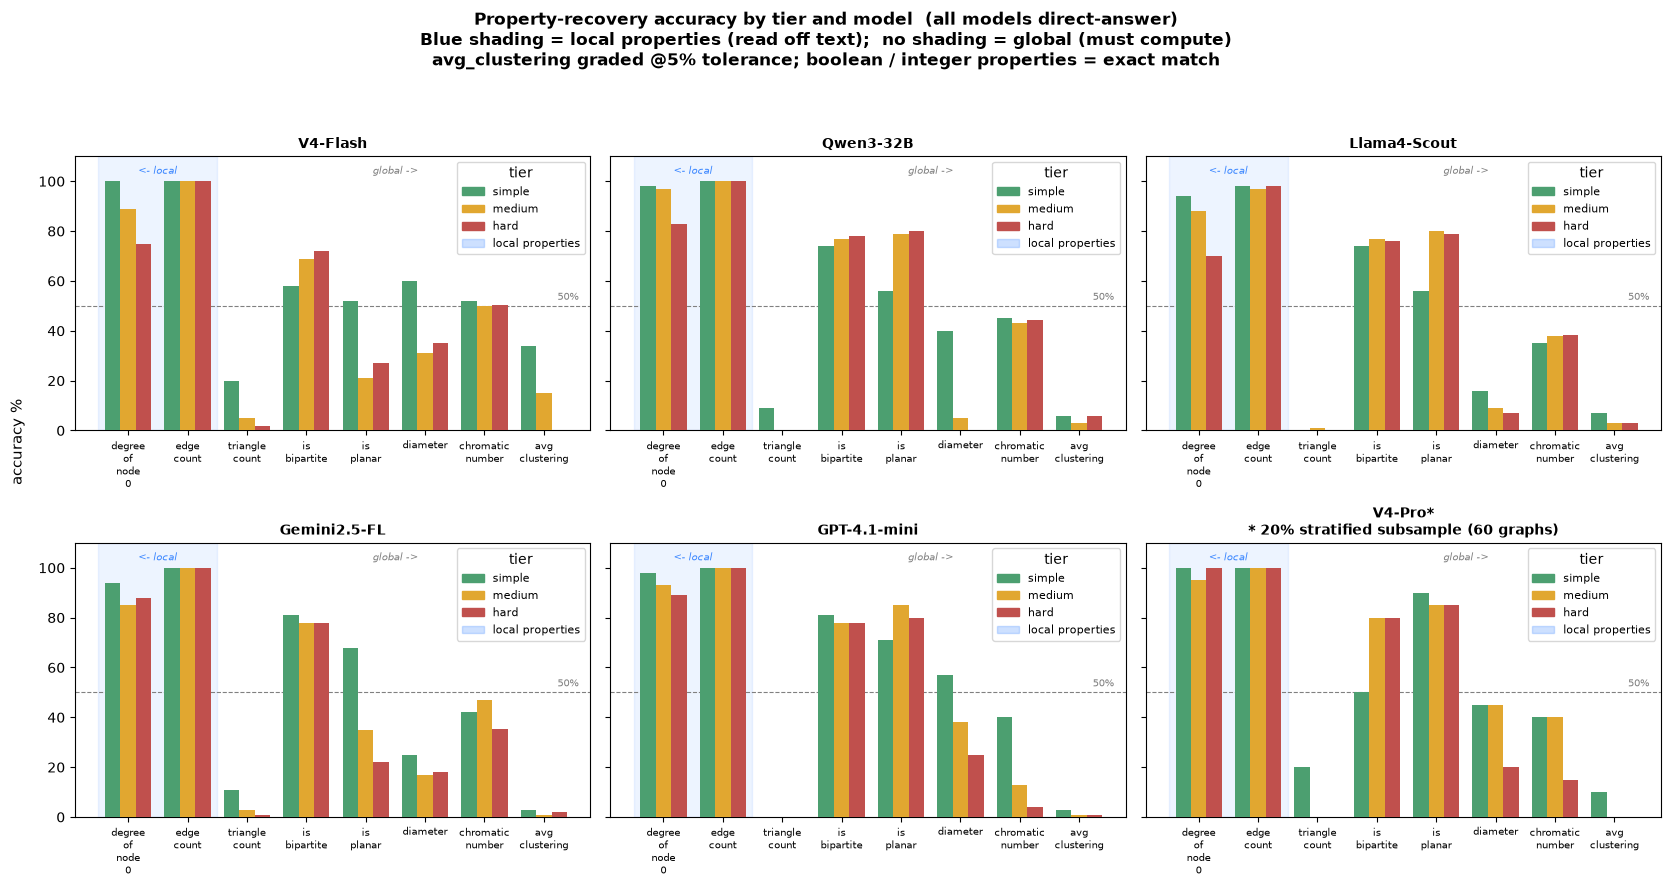

Saved /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/figures/fig1_accuracy_by_property.png


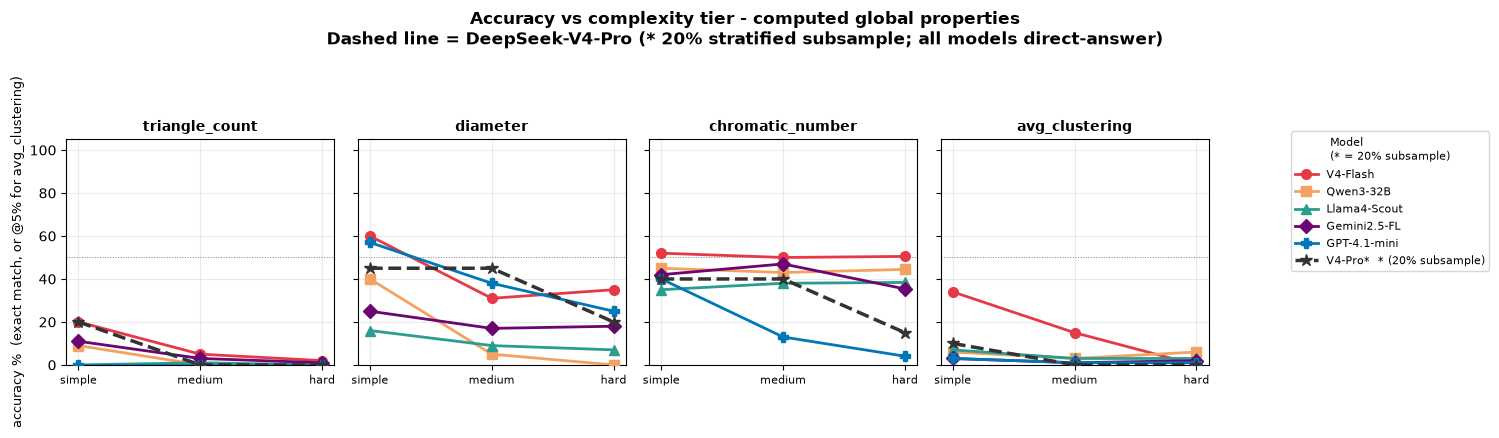

Saved /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/figures/fig2_accuracy_vs_complexity.png


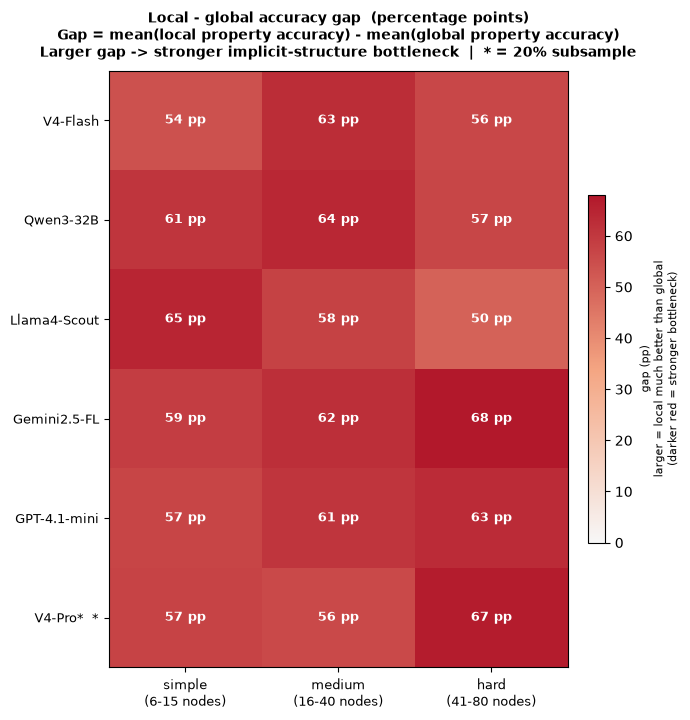

Saved /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/figures/fig3_local_global_gap_heatmap.png


In [17]:
for _m in MODELS_PRESENT:
    if _m not in MODEL_STYLE:
        print(f"WARNING: '{_m}' missing from MODEL_STYLE -> renders grey.")

# ---- FIG 1: accuracy by property, one panel per model ----
xlabels = [p.replace("_", "\n") for p in PROP_ORDER]
x = np.arange(len(PROP_ORDER))
w = 0.26
n_local = sum(1 for p in PROP_ORDER if p in LOCAL)

fig1, axes1 = plt.subplots(2, 3, figsize=(17, 9), sharey=True)
for ax, m in zip(axes1.flat, MODELS_PRESENT):
    for i, t in enumerate(TIERS):
        vals = [100 * (ACC[m][p][t] or 0) for p in PROP_ORDER]
        ax.bar(x + (i - 1) * w, vals, w, label=t, color=TIER_COLORS[t], zorder=3)
    ax.axvspan(-0.5, n_local - 0.5, color="#3A86FF", alpha=0.09, zorder=1)
    ax.text(n_local / 2 - 0.5, 102, "<- local", ha="center", va="bottom",
            fontsize=7.5, color="#3A86FF", style="italic")
    ax.text((n_local + len(PROP_ORDER)) / 2 - 0.5, 102, "global ->", ha="center",
            va="bottom", fontsize=7.5, color="grey", style="italic")
    ax.axhline(50, color="gray", ls="--", lw=0.8, zorder=2)
    ax.text(len(PROP_ORDER) - 0.4, 51.5, "50%", ha="right", va="bottom",
            fontsize=7, color="gray")
    title = DISPLAY.get(m, m)
    if m in SUBSAMPLE_MODELS:
        title += f"\n* 20% stratified subsample ({N_OBJECTS.get(m, '?')} graphs)"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=7.5)
    ax.set_ylim(0, 110)
    handles = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIERS]
    handles += [mpatches.Patch(color="#3A86FF", alpha=0.25, label="local properties")]
    ax.legend(handles=handles, title="tier", fontsize=8, loc="upper right",
              framealpha=0.9, edgecolor="lightgrey")
for ax in axes1.flat[len(MODELS_PRESENT):]:
    ax.axis("off")
fig1.suptitle(
    "Property-recovery accuracy by tier and model  (all models direct-answer)\n"
    "Blue shading = local properties (read off text);  no shading = global (must compute)\n"
    "avg_clustering graded @5% tolerance; boolean / integer properties = exact match",
    fontsize=12, fontweight="bold")
fig1.supylabel("accuracy %", fontsize=11)
plt.tight_layout(rect=[0.01, 0, 1, 0.94])
plt.savefig(FIG_DIR / "fig1_accuracy_by_property.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig1_accuracy_by_property.png'}")

# ---- FIG 2: accuracy vs complexity tier, line per model ----
fig2, axes2 = plt.subplots(1, len(COMPUTED_GLOBALS), figsize=(15, 4.0), sharey=True)
handles_fig2 = []
for ax, prop in zip(axes2, COMPUTED_GLOBALS):
    for m in MODELS_PRESENT:
        ys = [100 * (ACC[m][prop][t] or 0) for t in TIERS]
        s = mstyle(m)
        line, = ax.plot([0, 1, 2], ys, color=s["color"], ls=s["ls"], lw=s["lw"],
                        marker=s["marker"], markersize=s["ms"], label=mlabel(m), zorder=3)
        if prop == COMPUTED_GLOBALS[0]:
            handles_fig2.append(line)
    ax.set_title(prop, fontsize=10, fontweight="bold")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["simple", "medium", "hard"], fontsize=8)
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.25)
    ax.axhline(50, color="gray", ls=":", lw=0.7)
axes2[0].set_ylabel("accuracy %  (exact match, or @5% for avg_clustering)", fontsize=9)
fig2.legend(handles=handles_fig2, loc="center right", bbox_to_anchor=(1.0, 0.5),
            fontsize=8, framealpha=0.9, edgecolor="lightgrey",
            title="Model\n(* = 20% subsample)", title_fontsize=8)
fig2.suptitle("Accuracy vs complexity tier - computed global properties\n"
              "Dashed line = DeepSeek-V4-Pro (* 20% stratified subsample; all models direct-answer)",
              fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.82, 0.88])
plt.savefig(FIG_DIR / "fig2_accuracy_vs_complexity.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig2_accuracy_vs_complexity.png'}")

# ---- FIG 3: local-global gap heatmap (models x tier) ----
gap_grid = np.array([[GAP[m][t]["gap"] for t in TIERS] for m in MODELS_PRESENT], dtype=float)
fig3, ax3 = plt.subplots(figsize=(7.0, 0.75 * len(MODELS_PRESENT) + 2.8))
cmap_gap = LinearSegmentedColormap.from_list("gap", ["#f7f7f7", "#f4a582", "#b2182b"])
vmax = max(60, np.nanmax(gap_grid))
im = ax3.imshow(gap_grid, aspect="auto", cmap=cmap_gap, vmin=0, vmax=vmax)
ax3.set_xticks(range(len(TIERS)))
ax3.set_xticklabels(["simple\n(6-15 nodes)", "medium\n(16-40 nodes)",
                     "hard\n(41-80 nodes)"], fontsize=9)
ax3.set_yticks(range(len(MODELS_PRESENT)))
ax3.set_yticklabels([DISPLAY.get(m, m) + ("  *" if m in SUBSAMPLE_MODELS else "")
                     for m in MODELS_PRESENT], fontsize=9)
for i in range(len(MODELS_PRESENT)):
    for j in range(len(TIERS)):
        v = gap_grid[i, j]
        ax3.text(j, i, f"{v:.0f} pp", ha="center", va="center",
                 color=("white" if v > vmax * 0.55 else "black"),
                 fontsize=9, fontweight="bold")
ax3.set_title("Local - global accuracy gap  (percentage points)\n"
              "Gap = mean(local property accuracy) - mean(global property accuracy)\n"
              "Larger gap -> stronger implicit-structure bottleneck  |  * = 20% subsample",
              fontsize=10, fontweight="bold", pad=10)
cbar = fig3.colorbar(im, ax=ax3, fraction=0.035, pad=0.04)
cbar.set_label("gap (pp)\nlarger = local much better than global\n(darker red = stronger bottleneck)",
               fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_local_global_gap_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig3_local_global_gap_heatmap.png'}")

## [CELL 14] DeepSeek-V4-Flash failure-mode analysis (section 7, deliverable 6)

In [18]:
FAIL_MODEL = "deepseek-v4-flash" if "deepseek-v4-flash" in MODELS_PRESENT else MODELS_PRESENT[0]


def classify_failure(r):
    """Heuristic Table-14 label for a FAILED record. Starter for manual review.
    Table 14's graph-domain examples: serialization_misread = 'misidentified
    which nodes are connected'; structural_reasoning_error = 'wrong planarity
    or bipartiteness judgment'. Table 14's off-by-one/definition example
    (geometry's closing-coordinate) has a direct graph-domain analogue:
    diameter has two common definitions -- edges on the longest shortest path
    (this dataset's ground truth) vs. nodes on that path (= edges + 1) -- so an
    absolute_error of exactly 1 on diameter is classified as a definitional
    mismatch rather than an arithmetic error."""
    p, pa, gt = r["property"], r["parsed_answer"], r["ground_truth"]
    ae, re_ = r.get("absolute_error"), r.get("relative_error")
    if not r.get("parse_success"):
        return "parse_failure"
    if r.get("finish_reason") == "length" or r.get("failure_type") == "reasoning_truncated":
        return "reasoning_truncated"
    if p in LOCAL:                                    # degree_of_node_0, edge_count
        return "serialization_misread"
    if p in BOOLEAN:                                   # is_bipartite, is_planar
        return "structural_reasoning_error"
    if p == "avg_clustering":
        if re_ is None or re_ > 1.0:
            return "hallucination"
        return "arithmetic_error"
    if p in ("triangle_count",):                        # can legitimately be large
        if ae is None or (isinstance(gt, (int, float)) and gt >= 0 and ae > max(5, gt)):
            return "hallucination"
        return "arithmetic_error"
    if p == "diameter":
        if ae == 1:                                    # edges-vs-nodes-on-path ambiguity
            return "off_by_one_definition"
        if ae is None or ae > 3:
            return "hallucination"
        return "arithmetic_error"
    if p == "chromatic_number":                          # small bounded integer, no known definitional ambiguity
        if ae is None or ae > 3:
            return "hallucination"
        return "arithmetic_error"
    return "other"


vf = sub(model=FAIL_MODEL)
failures = [r for r in vf if not unified_correct(r)]
for r in failures:
    r["_fail_label"] = classify_failure(r)

print(f"FAILURE-MODE ANALYSIS - {DISPLAY[FAIL_MODEL]}  (heuristic starter; manual review required)")
print(f"  total queries {len(vf)}  |  failures {len(failures)} ({100*len(failures)/len(vf):.0f}%)\n")

dist = Counter(r["_fail_label"] for r in failures)
print("  Failure-mode distribution (all failures):")
for lab, n in dist.most_common():
    print(f"    {lab:26s} {n:5d}  ({100*n/len(failures):4.1f}%)")

print("\n  By property locality:")
for loc in ("local", "global"):
    fl = [r for r in failures if (r["property"] in LOCAL) == (loc == "local")]
    if not fl:
        continue
    lc = Counter(r["_fail_label"] for r in fl)
    top = ", ".join(f"{k} {100*v/len(fl):.0f}%" for k, v in lc.most_common(3))
    print(f"    {loc:6s} (n={len(fl):4d}): {top}")

print("\n  By tier:")
for t in TIERS:
    ft = [r for r in failures if r["tier"] == t]
    if not ft:
        continue
    tc = Counter(r["_fail_label"] for r in ft)
    top = ", ".join(f"{k} {100*v/len(ft):.0f}%" for k, v in tc.most_common(3))
    print(f"    {t:6s} (n={len(ft):4d}): {top}")

random.seed(RNG_SEED)
review = []
for t in TIERS:
    for loc in ("local", "global"):
        pool = [r for r in failures
                if r["tier"] == t and ((r["property"] in LOCAL) == (loc == "local"))]
        review += random.sample(pool, min(6, len(pool)))
review_ids = {id(r) for r in review}

print(f"\n  STRATIFIED MANUAL-REVIEW SAMPLE - {len(review)} failures (target >=30, covers all "
      f"tiers x localities). Hand-label each, correcting the heuristic guess:")
print(f"    {'object_id':26s} {'property':18s} {'tier':7s} {'heuristic_label':24s} {'abs/rel err':>12s}")
for r in review:
    err = r.get("relative_error", r.get("absolute_error"))
    print(f"    {r['object_id']:26s} {r['property']:18s} {r['tier']:7s} "
          f"{r['_fail_label']:24s} {('%.2f' % err) if err is not None else '     n/a':>12s}")

FAILURE_LOG = [{
    "model": FAIL_MODEL, "object_id": r["object_id"], "tier": r["tier"],
    "family": r["family"], "property": r["property"],
    "locality": "local" if r["property"] in LOCAL else "global",
    "ground_truth": r["ground_truth"], "parsed_answer": r["parsed_answer"],
    "relative_error": r.get("relative_error"), "absolute_error": r.get("absolute_error"),
    "heuristic_label": r["_fail_label"],
    "manual_label": None,
    "in_review_sample": id(r) in review_ids,
} for r in failures]

_fail_path = OUT_DIR / "v4flash_failure_analysis.json"
_fail_path.write_text(json.dumps(FAILURE_LOG, indent=2))
print(f"\n  Wrote {_fail_path}  ({len(FAILURE_LOG)} labeled failures, "
      f"'manual_label' blank for you to fill).")

print("\n  CAVEAT: labels are heuristic. The arithmetic_error vs hallucination split is the "
      "least reliable, and instruction_failure isn't auto-detected. Verify on the sample "
      "above before quoting any percentage.")

FAILURE-MODE ANALYSIS - V4-Flash  (heuristic starter; manual review required)
  total queries 2399  |  failures 1182 (49%)

  Failure-mode distribution (all failures):
    arithmetic_error             590  (49.9%)
    structural_reasoning_error   301  (25.5%)
    off_by_one_definition        144  (12.2%)
    hallucination                 98  ( 8.3%)
    serialization_misread         36  ( 3.0%)
    parse_failure                 13  ( 1.1%)

  By property locality:
    local  (n=  36): serialization_misread 100%
    global (n=1146): arithmetic_error 51%, structural_reasoning_error 26%, off_by_one_definition 13%

  By tier:
    simple (n= 324): arithmetic_error 58%, structural_reasoning_error 28%, off_by_one_definition 11%
    medium (n= 420): arithmetic_error 45%, structural_reasoning_error 26%, off_by_one_definition 15%
    hard   (n= 438): arithmetic_error 48%, structural_reasoning_error 23%, off_by_one_definition 11%

  STRATIFIED MANUAL-REVIEW SAMPLE - 30 failures (target >=30, cove

## [CELL 15] Section 9 decision-rule readout + saved summary (deliverable 8)

In [19]:
CAPPED = [m for m in MODELS_PRESENT if m not in SUBSAMPLE_MODELS]
GLOBAL_PROPS = [p for p in PROP_ORDER if p not in LOCAL]
HAS_V4PRO = "deepseek-v4-pro" in MODELS_PRESENT


def _lt(v, thr):
    return (v is not None) and (v < thr)


def _ge(v, thr):
    return (v is not None) and (v >= thr)


def parsefail_rate(recs):
    if not recs:
        return 0.0
    return sum(1 for r in recs if (not r.get("parse_success")) or is_truncated(r)) / len(recs)


print("SECTION 9 DECISION-RULE COMPONENTS  (graphs; capped direct-answer models)\n")
print(f"  {'model':13s} {'globals<70(m/h)':>15s} {'local>=85(m&h)':>15s} {'gap(pp)':>9s} {'parsefail':>10s}")
n_global_ok = 0
for m in CAPPED:
    below = [p for p in GLOBAL_PROPS
             if _lt(ACC[m][p]["medium"], 0.70) or _lt(ACC[m][p]["hard"], 0.70)]
    local_ok = all(_ge(ACC[m][p]["medium"], 0.85) and _ge(ACC[m][p]["hard"], 0.85) for p in LOCAL)
    g = GAP[m]["overall"]["gap"]
    pf = parsefail_rate(sub(model=m))
    n_global_ok += (len(below) >= 2)
    print(f"  {DISPLAY[m]:13s} {len(below):>15d} {str(local_ok):>15s} {g:>+9.1f} {100*pf:>9.1f}%")

all_above_85_hard = all(_ge(ACC[m][p]["hard"], 0.85) for m in CAPPED for p in PROP_ORDER)
any_parsefail_15 = any(parsefail_rate(sub(model=m, prop=p)) > 0.15
                       for m in CAPPED for p in PROP_ORDER)
gaps = [GAP[m]["overall"]["gap"] for m in CAPPED if GAP[m]["overall"]["gap"] is not None]
max_gap, min_gap = (max(gaps), min(gaps)) if gaps else (None, None)
global_criterion_met = n_global_ok >= 4

print("\nSECTION 9 OUTCOME EVALUATION (graph domain):")
print(f"  A. Proceed as planned  - >=2 globals <70% on med/hard w/ local high: "
      f"global-failure met by {n_global_ok}/{len(CAPPED)} models  -> "
      f"{'YES' if global_criterion_met else 'no'}")
print(f"  B. Modified emphasis   - gap present but <15pp: gaps are "
      f"{min_gap:+.0f}..{max_gap:+.0f}pp  -> {'YES' if (max_gap is not None and max_gap < 15) else 'no'}")
print(f"  C. Reassess design     - all props >85% on hard: {all_above_85_hard}  -> "
      f"{'YES' if all_above_85_hard else 'no'}")
print(f"  D. Fix harness         - any parse-fail >15%: {any_parsefail_15}  -> "
      f"{'YES' if any_parsefail_15 else 'no'}")

graph_outcome = ("A (proceed as planned)"
                 if (global_criterion_met and not all_above_85_hard
                     and not any_parsefail_15 and max_gap is not None and max_gap >= 15)
                 else "see components")
print(f"\n  => GRAPHS support OUTCOME {graph_outcome}")

print("\nNUANCES TO CARRY INTO THE WRITE-UP:")
print("  1. Unlike geometry, both local properties (degree_of_node_0, edge_count) are")
print("     simple integer reads with no size-dependent counting ambiguity analogous to")
print("     geometry's closing-coordinate issue -- a 'local degrades with size' finding")
print("     here would be a genuine reading-at-scale effect, not a definitional artifact.")
print("  2. This is the SECOND domain evaluated (after geometry). The Section 9 rule")
print("     needs >=2 of 3 domains to agree before the final go/no-go; check this")
print("     against the geometry decision in ../phase3_evaluation/results/evaluation_summary.txt.")
if HAS_V4PRO:
    v4pro_glob = acc(sub(model="deepseek-v4-pro", locality="global"))
    v4pro_gap = GAP["deepseek-v4-pro"]["overall"]["gap"]
    print(f"  3. MITIGATION SIGNAL: V4-Pro* (free reasoning) reaches {pct(v4pro_glob)}% global")
    print("     accuracy - if much higher than the capped models, the bottleneck is")
    print("     single-pass/no-CoT, not fundamental inability (same read as geometry).")

# ---- assemble + save summary ----
lines = []
lines.append("EXPERIMENT 1 - GRAPH DOMAIN - PHASE 3 EVALUATION SUMMARY")
lines.append("=" * 60)
lines.append("Task: recover 8 properties from text-serialized (edge-list) graphs.")
lines.append(f"Models: {', '.join(DISPLAY[m] for m in MODELS_PRESENT)}")
lines.append("Coverage: " + "; ".join(
    f"{DISPLAY[m]} {N_OBJECTS[m]} graphs / {len(sub(model=m))} queries" for m in MODELS_PRESENT))
lines.append("")
lines.append("HEADLINE: local-vs-global accuracy gap, all capped models.")
for m in sorted(CAPPED, key=lambda x: -(GAP[x]["overall"]["gap"] or -1)):
    g = GAP[m]["overall"]
    lines.append(f"  {DISPLAY[m]:13s} gap {g['gap']:+5.1f}pp  [{g['lo']:+.1f},{g['hi']:+.1f}]  p={g['p']:.4f}")
lines.append("")
lines.append("MECHANISM: compute failure, not read failure (expected pattern, per-model detail above).")
lines.append("  - degree_of_node_0 / edge_count (readable) vs. triangle_count / diameter /")
lines.append("    chromatic_number / avg_clustering (must compute over the whole structure).")
lines.append("  - is_bipartite / is_planar: compare acc vs. base-rate baseline in Cell 7's tables.")
if off:
    lines.append(f"  - cross-model Spearman rho = {np.mean(off):.2f} among capped models: "
                 f"one shared difficulty ordering.")
lines.append("")
if HAS_V4PRO:
    lines.append(f"PIVOTAL: V4-Pro* (free reasoning) gap {v4pro_gap:+.1f}pp, "
                 f"globals {pct(v4pro_glob)}%.")
    lines.append("  => compare against geometry's equivalent line to see if the same")
    lines.append("     single-pass / no-chain-of-thought story holds cross-domain.")
    lines.append("")
lines.append(f"{DISPLAY[FAIL_MODEL]} FAILURE MODES (heuristic, n={len(failures)}): " +
             ", ".join(f"{k} {100*v/len(failures):.0f}%" for k, v in dist.most_common(4)) +
             " (manual review pending).")
lines.append("")
lines.append(f"DECISION (section 9): graphs support OUTCOME {graph_outcome}.")
lines.append(f"  - global-failure criterion met by {n_global_ok}/{len(CAPPED)} capped models.")
lines.append("  - FINAL multi-domain go/no-go: compare against geometry's decision; needs")
lines.append("    >=2 of 3 domains to agree (tabular domain not yet evaluated).")

summary = "\n".join(lines)
_sum_path = OUT_DIR / "evaluation_summary.txt"
_sum_path.write_text(summary)

print("\n" + "=" * 60)
print(summary)
print("=" * 60)
print(f"\nSaved: {_sum_path}")

SECTION 9 DECISION-RULE COMPONENTS  (graphs; capped direct-answer models)

  model         globals<70(m/h)  local>=85(m&h)   gap(pp)  parsefail
  V4-Flash                    6           False     +57.7       0.5%
  Qwen3-32B                   4           False     +60.5       0.0%
  Llama4-Scout                4           False     +57.5       1.2%
  Gemini2.5-FL                5            True     +63.0       0.1%
  GPT-4.1-mini                4            True     +60.3       0.0%

SECTION 9 OUTCOME EVALUATION (graph domain):
  A. Proceed as planned  - >=2 globals <70% on med/hard w/ local high: global-failure met by 5/5 models  -> YES
  B. Modified emphasis   - gap present but <15pp: gaps are +58..+63pp  -> no
  C. Reassess design     - all props >85% on hard: False  -> no
  D. Fix harness         - any parse-fail >15%: False  -> no

  => GRAPHS support OUTCOME A (proceed as planned)

NUANCES TO CARRY INTO THE WRITE-UP:
  1. Unlike geometry, both local properties (degree_of_node_0,

## [CELL 16] Figures 4-5

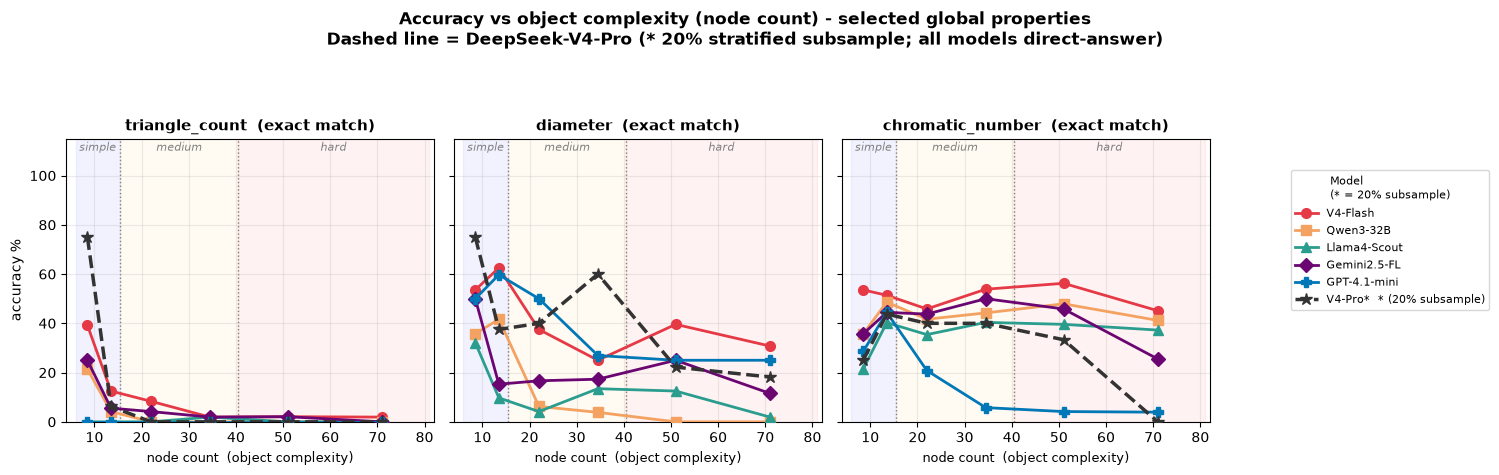

Saved /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/figures/fig4_accuracy_vs_nodecount.png


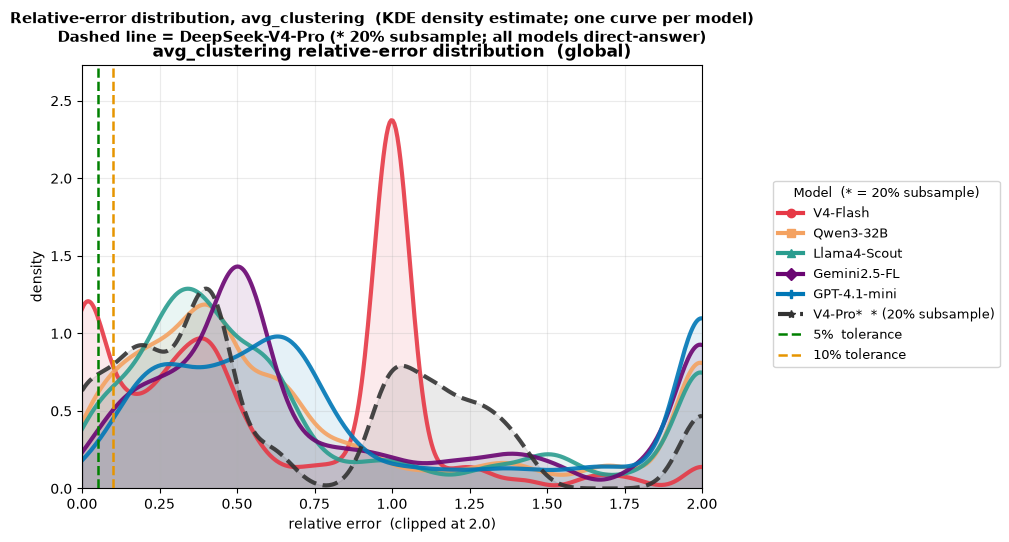

Saved /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/figures/fig5_error_histogram.png

PHASE 3 EVALUATION COMPLETE.
  figures -> /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/figures
  results -> /home/mobin/Desktop/Work/Hivemind/serialization-bottleneck/phase3_evaluation_graph/results


In [20]:
# ---- FIG 4: accuracy vs object complexity (node count) - selected global properties ----
NODE_EDGES = [6, 11, 16, 28, 41, 61, 81]
NODE_MID = [(NODE_EDGES[i] + NODE_EDGES[i + 1]) / 2 for i in range(len(NODE_EDGES) - 1)]
SEL_GLOBAL = ["triangle_count", "diameter", "chromatic_number"]


def binned_accuracy(model, prop):
    xs, ys = [], []
    for i in range(len(NODE_EDGES) - 1):
        lo, hi = NODE_EDGES[i], NODE_EDGES[i + 1]
        rr = [r for r in sub(model=model, prop=prop)
              if r.get("num_nodes") is not None and lo <= r["num_nodes"] < hi]
        if rr:
            xs.append(NODE_MID[i])
            ys.append(100 * acc(rr))
    return xs, ys


fig4, axes4 = plt.subplots(1, len(SEL_GLOBAL), figsize=(15, 4.8), sharey=True)
handles_fig4 = []
for ax, prop in zip(axes4, SEL_GLOBAL):
    for m in MODELS_PRESENT:
        xs, ys = binned_accuracy(m, prop)
        if xs:
            s = mstyle(m)
            line, = ax.plot(xs, ys, color=s["color"], ls=s["ls"], lw=s["lw"],
                            marker=s["marker"], markersize=s["ms"], label=mlabel(m), zorder=3)
            if prop == SEL_GLOBAL[0]:
                handles_fig4.append(line)
    ax.axvspan(6, 15.5, alpha=0.05, color="blue")
    ax.axvspan(15.5, 40.5, alpha=0.05, color="orange")
    ax.axvspan(40.5, 81, alpha=0.05, color="red")
    ax.axvline(15.5, color="grey", ls=":", lw=1.0, zorder=1)
    ax.axvline(40.5, color="grey", ls=":", lw=1.0, zorder=1)
    for xc, lbl in [(10.7, "simple"), (28.0, "medium"), (60.7, "hard")]:
        ax.text(xc, 109, lbl, ha="center", va="bottom", fontsize=8,
                color="grey", style="italic")
    ax.set_title(f"{prop}  (exact match)", fontsize=11, fontweight="bold")
    ax.set_xlabel("node count  (object complexity)", fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_xlim(4, 82)
    ax.grid(alpha=0.25)
axes4[0].set_ylabel("accuracy %", fontsize=10)
fig4.legend(handles=handles_fig4, loc="center right", bbox_to_anchor=(1.0, 0.5),
            fontsize=8, framealpha=0.9, edgecolor="lightgrey",
            title="Model\n(* = 20% subsample)", title_fontsize=8)
fig4.suptitle("Accuracy vs object complexity (node count) - selected global properties\n"
              "Dashed line = DeepSeek-V4-Pro (* 20% stratified subsample; all models direct-answer)",
              fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.82, 0.90])
plt.savefig(FIG_DIR / "fig4_accuracy_vs_nodecount.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig4_accuracy_vs_nodecount.png'}")

# ---- FIG 5: relative-error distribution (KDE) for avg_clustering ----
# Only one numeric-tolerance property exists in this domain (Cell 1), so this is
# a single panel rather than Geometry's 2x3 grid -- a real domain difference,
# not a simplification.
CLIP = 2.0
X_KDE = np.linspace(0, CLIP, 400)


def model_errors(model, prop):
    vals = [r["relative_error"] for r in sub(model=model, prop=prop)
            if r.get("relative_error") is not None and np.isfinite(r["relative_error"])]
    return np.clip(np.asarray(vals, float), 0, CLIP)


def kde_curve(errs):
    if errs.size < 8:
        return None, None
    try:
        kde = gaussian_kde(errs, bw_method=0.12)
        return X_KDE, kde(X_KDE)
    except Exception:
        return None, None


fig5, ax5 = plt.subplots(figsize=(8, 5.5))
model_handles = [plt.Line2D([0], [0], color=mstyle(m)["color"], lw=3.0, ls=mstyle(m)["ls"],
                            marker=mstyle(m)["marker"], markersize=6, label=mlabel(m))
                 for m in MODELS_PRESENT]
tol_handles = [plt.Line2D([0], [0], color="green", ls="--", lw=1.8, label="5%  tolerance"),
               plt.Line2D([0], [0], color="#E69500", ls="--", lw=1.8, label="10% tolerance")]

y_max = 0.0
for m in MODELS_PRESENT:
    errs = model_errors(m, "avg_clustering")
    if errs.size == 0:
        continue
    s = mstyle(m)
    x_k, y_k = kde_curve(errs)
    if x_k is not None:
        ax5.fill_between(x_k, y_k, color=s["color"], alpha=0.10)
        ax5.plot(x_k, y_k, color=s["color"], lw=3.0, ls=s["ls"], alpha=0.90)
        y_max = max(y_max, y_k.max())
    else:
        counts, edges = np.histogram(errs, bins=np.linspace(0, CLIP, 41), density=True)
        ax5.stairs(counts, edges, color=s["color"], lw=2.5, ls=s["ls"])
        y_max = max(y_max, counts.max())
ax5.axvline(0.05, color="green", ls="--", lw=1.8, zorder=5)
ax5.axvline(0.10, color="#E69500", ls="--", lw=1.8, zorder=5)
ax5.set_ylim(0, max(y_max * 1.15, 0.5))
ax5.set_title("avg_clustering relative-error distribution  (global)", fontsize=12, fontweight="bold")
ax5.set_xlabel("relative error  (clipped at 2.0)", fontsize=10)
ax5.set_ylabel("density", fontsize=10)
ax5.set_xlim(0, CLIP)
ax5.grid(alpha=0.25)
fig5.legend(handles=model_handles + tol_handles, loc="center right",
            bbox_to_anchor=(1.28, 0.5), fontsize=9, framealpha=0.97,
            edgecolor="lightgrey", title="Model  (* = 20% subsample)", title_fontsize=9)
fig5.suptitle("Relative-error distribution, avg_clustering  (KDE density estimate; one curve per model)\n"
              "Dashed line = DeepSeek-V4-Pro (* 20% subsample; all models direct-answer)",
              fontsize=11, fontweight="bold")
plt.savefig(FIG_DIR / "fig5_error_histogram.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig5_error_histogram.png'}")

print("\nPHASE 3 EVALUATION COMPLETE.")
print(f"  figures -> {FIG_DIR}")
print(f"  results -> {OUT_DIR}")